# Tripartite Population Dynamics- paper 1

# Problem 2
We model a closed, well-mixed batch culture, where three microbial strategies co-exist: a public metabolizer $(P)$, cheater $(C)$, and a private metabolizer $(M)$.
Sucrose is continuously supplied as the sole carbon source. 
The public metabolizer secretes  extracellular invertase, hydrolyzing sucrose into glucose in the surrounding medium. 
This glucose is partially assimilated for its own growth, while the rest becomes part of a common resource pool accessible to other community members. 
Cheaters exploit this resource pool without contributing the enzyme themselves, and their growth is thus dependent on the availability of shared glucose.
In contrast, private metabolizers internalize sucrose and cleave it intracellularly, thereby bypassing the common pool and avoiding cross-feeding interactions altogether. 

To describe the ecological dynamics of these three strategies, we employ a nonlinear Lotka–Volterra framework that captures intrinsic growth, pairwise interactions, and density-dependent effects. 
Importantly, we assume that public metabolizers constitutively express invertase at a constant rate throughout their lifetime. 
Consequently, we do not explicitly model the dynamics of enzyme regulation, as is common in other approaches \cite{}. 
This assumption allows us to avoid explicitly modeling enzyme regulation, thereby reducing model complexity. At the same time, it preserves ecological realism, since cheater growth remains directly dependent on the activity and density of public metabolizers.

The resulting system is governed by a set of coupled ordinary differential equations:
\begin{equation}\label{eq:LV} 
\begin{cases}
\frac{dP}{dt} & = r_p \cdot P - \alpha \cdot P\cdot C - \beta \cdot P \cdot M - \eta \cdot P ^2 \\
\frac{dC}{dt}  & = \alpha \cdot P\cdot C - \nu \cdot C^2 \\
\frac{dM}{dt} & = r_m \cdot M - \beta \cdot M \cdot P - \gamma \cdot M^2
\end{cases}
\end{equation} 
with seven parameters: intrinsic growth rates ($r_p$, $ r_m $), cooperation parameters ($ \alpha $) and competition ($ \beta $), and density ($ \eta$,$ \gamma$, $ \nu$ ).
The cheater population does not contribute to enzyme production and relies entirely on the glucose released by public metabolizers. Its growth rate is therefore jointly determined by the cooperation coefficient $ \alpha $ and the density of public metabolizers.
However, to prevent uncontrolled proliferation, cheater growth is also regulated by density-dependent constraints $\nu$. 
This model is designed to be readily parameterizable from empirical data.
To ensure broad applicability and experimental integration, we present a stepwise protocol for parameter estimation based on monoculture and pairwise co-culture experiments. This framework enables researchers to directly map ecological interactions onto measurable population dynamics, bridging theoretical modeling with empirical observation.


# problem 1
- Proportion of Public population :  

$$
P^* \;=\;\frac{r_p\,\gamma \;-\;\beta\,r_m}{\alpha^2\,\gamma \;+\;\nu\,\eta\,\gamma \;-\;\nu\,\beta^2}
$$
- Proportion of Cheaters :  
$$
C^* \;=\;\frac{\alpha\,\bigl(r_p\,\gamma \;-\;\beta\,r_m\bigr)}{\alpha^2\,\gamma \;+\;\nu\,\eta\,\gamma \;-\;\nu\,\beta^2}
$$

- Proportion of Privates :  

$$
M^* \;=\;\frac{\alpha^2\,r_m \;+\;\eta\,\nu\,r_m \;-\;\beta\,\nu\,r_p}{\alpha^2\,\gamma \;+\;\nu\,\eta\,\gamma \;-\;\nu\,\beta^2}
$$


These expressions describe the equilibrium point where all three strategies coexist in the population. The coexistence of $ P$, $ C $, and $ M $ in the mixed ESS represents a delicate balance governed by intrinsic growth rates, competition, and exploitation dynamics.

### Imports

In [3]:
from src.model import deriv
from src.parameters import parameters
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
import os

## test analysis

In [4]:
from src.parameters import parameters
print(parameters)


{'beta': 0.0001, 'gamma': 0.0001, 'alpha': 0.0003, 'eta': 0.0001, 'r_c': 2.0, 'r_p': 1.0, 'nu': 0.0001}


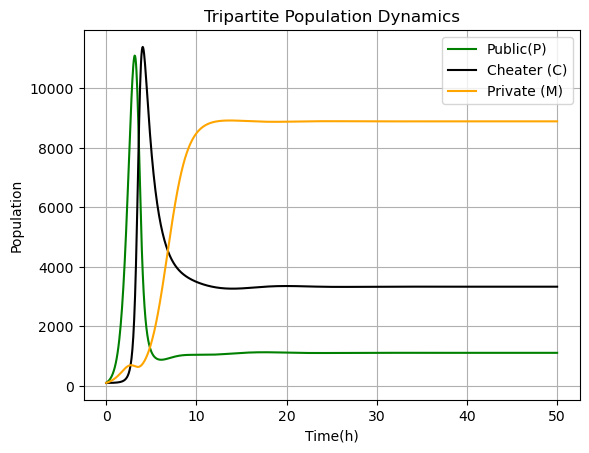

In [6]:
y0 =100.0, 100.0, 100.0
t = np.linspace(0,50,1000)
ret = odeint(deriv,y0,t,args=(
parameters["nu"],
parameters["beta"],
parameters["alpha"],
parameters["r_p"],
parameters["r_m"],
parameters["gamma"],
parameters["eta"],
))

# Plot results
plt.figure()
plt.plot(t, ret[:, 0], label="Public(P)", color='green')
plt.plot(t, ret[:, 1], label="Cheater (C)",color='black' )
plt.plot(t, ret[:, 2], label="Private (M)", color='orange')
plt.xlabel("Time(h)")
plt.ylabel("Population")
plt.title("Tripartite Population Dynamics")
plt.legend()
plt.grid()
plt.savefig("output/figures/fig1.png", dpi=300)
plt.show()

# Different growth conditions

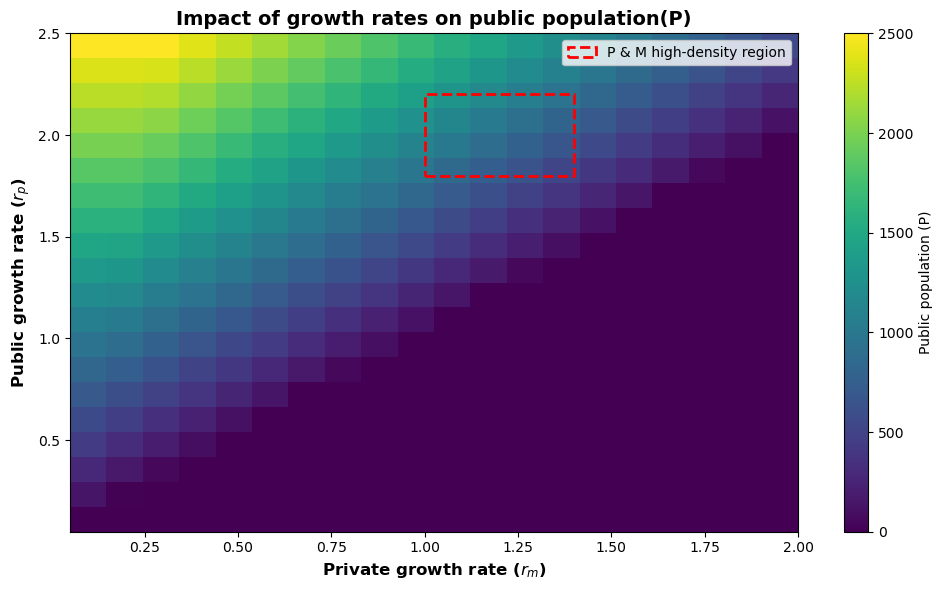

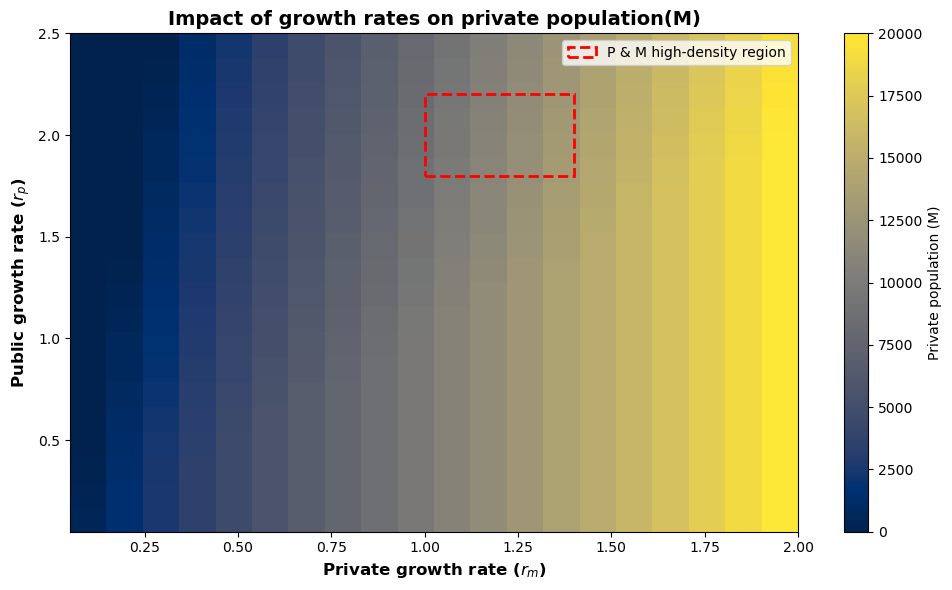

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from src.model import deriv  # Import the model function
from src.parameters import parameters  # Import the parameters dictionary

# Simulation configuration
y0 = 100.0, 100.0, 100.0  # Initial populations of [C, D, P]
T = 300  # Total simulation time
dt = 0.1  # Time step
n_steps = int(T / dt)
time = np.linspace(0, T, n_steps)

# Range of r_c and r_p values to test
r_c_values = np.linspace(0.05, 2.5, 20)
r_p_values = np.linspace(0.05, 2.0, 20)

# Arrays to store final population sizes for each (r_c, r_p) combination
final_C = np.zeros((len(r_c_values), len(r_p_values)))
final_D = np.zeros((len(r_c_values), len(r_p_values)))
final_P = np.zeros((len(r_c_values), len(r_p_values)))

# Simulate for each combination of r_c and r_p
for i, r_c in enumerate(r_c_values):
    for j, r_p in enumerate(r_p_values):
        # Update the parameters for the current r_c and r_p
        parameters["r_c"] = r_c
        parameters["r_p"] = r_p

        # Run the simulation using the ODE solver
        ret = odeint(
            deriv, y0, time, args=(
                parameters["nu"],
                parameters["beta"],
                parameters["alpha"],
                parameters["r_c"],
                parameters["r_p"],
                parameters["gamma"],
                parameters["eta"],
            )
        )

        # Record final populations
        final_C[i, j] = ret[-1, 0]  # Final Public population (C)
        final_D[i, j] = ret[-1, 1]  # Final Cheater population (D)
        final_P[i, j] = ret[-1, 2]  # Final Private population (P)

# Plotting heatmap for final cooperators (C) as r_c and r_p vary
plt.figure(figsize=(10, 6))
plt.imshow(final_C, aspect='auto', origin='lower',
           extent=[r_p_values[0], r_p_values[-1], r_c_values[0], r_c_values[-1]],
           cmap='viridis')
plt.colorbar(label='Public population (P)')
plt.xlabel('Private growth rate ($r_m$)', fontsize=12, fontweight="bold")
plt.ylabel('Public growth rate ($r_p$)', fontsize=12, fontweight="bold")
plt.title('Impact of growth rates on public population(P)', fontsize=14, fontweight="bold")

# Highlight high-density region for Public population with a box
plt.gca().add_patch(plt.Rectangle((1.0, 1.8), 0.4, 0.4, edgecolor='red', facecolor='none', lw=2, linestyle='--', label='P & M high-density region'))
plt.legend(fontsize=10)
plt.tight_layout()
os.makedirs("output/figures", exist_ok=True)
plt.savefig("output/figures/public_population_heatmap.png", dpi=300)
plt.show()

# Plotting heatmap for final private populations (P) as r_c and r_p vary
plt.figure(figsize=(10, 6))
plt.imshow(final_P, aspect='auto', origin='lower',
           extent=[r_p_values[0], r_p_values[-1], r_c_values[0], r_c_values[-1]],
           cmap='cividis')
plt.colorbar(label='Private population (M)')
plt.xlabel('Private growth rate ($r_m$)', fontsize=12, fontweight="bold")
plt.ylabel('Public growth rate ($r_p$)', fontsize=12, fontweight="bold")
plt.title('Impact of growth rates on private population(M)', fontsize=14, fontweight="bold")

# Highlight high-density region for Private population with a box
plt.gca().add_patch(plt.Rectangle((1.0, 1.8), 0.4, 0.4, edgecolor='red', facecolor='none', lw=2, linestyle='--', label='P & M high-density region'))
plt.legend(fontsize=10)
plt.tight_layout()
os.makedirs("output/figures", exist_ok=True)
plt.savefig("output/figures/private_population_heatmap.png", dpi=300)
plt.show()


# Game Theory( 3 species and 3 streatgy)

# 1. Game theory payoff  analysis

# problem two

# Shift in population(main )

# Growth rate shifting(payoff advantage)

# simplex_replicator_dynamics( exp approch for finding solution)

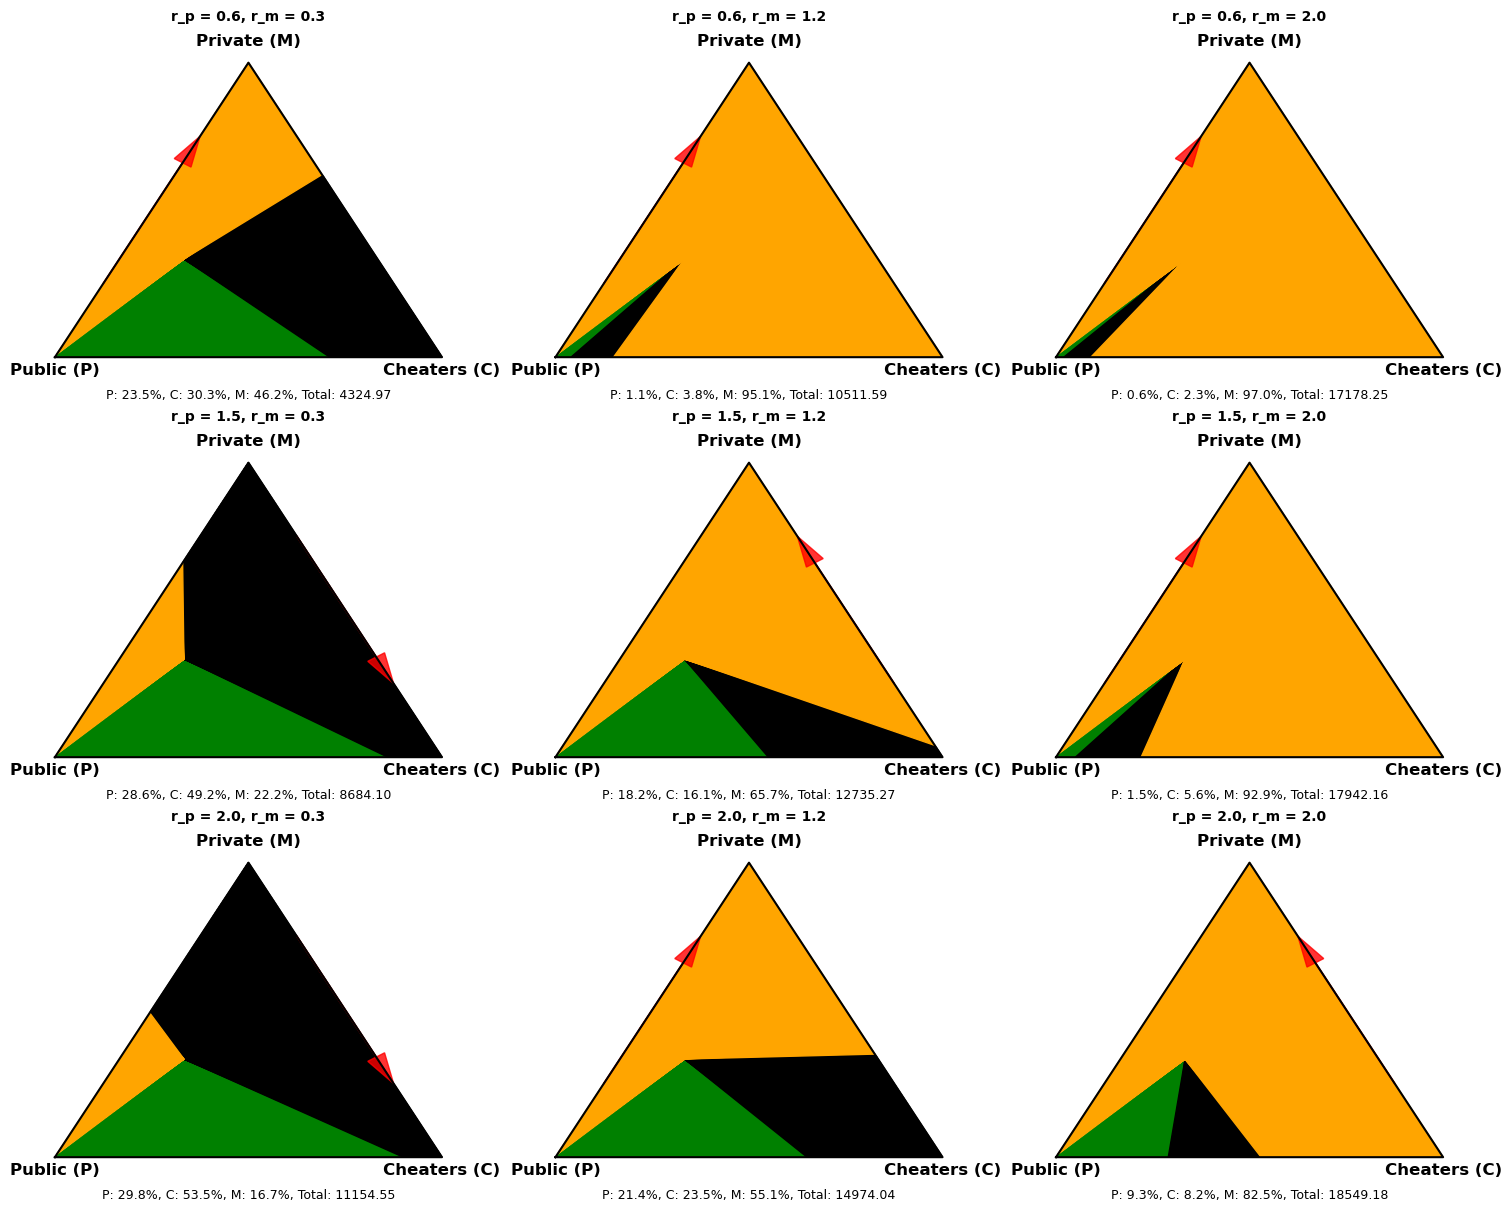

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import os

# Parameters
parameters = {
    "r_p": 0.02,
    "r_m": 0.02,
    "alpha": 0.0002,
    "beta": 0.0001,
    "eta": 0.0001,
    "gamma": 0.0001,
    "nu": 0.00001
}

# Growth rate variations
rp_values = [.6, 1.5, 2.0]
rm_values = [.3, 1.2, 2.0]

fig, axes = plt.subplots(len(rp_values), len(rm_values), figsize=(15, 12), constrained_layout=True)

# Function to convert barycentric coordinates to cartesian
def to_cartesian(x):
    return np.array([
        0.5 * (2 * x[:, 1] + x[:, 2]),
        np.sqrt(3) / 2 * x[:, 2]
    ]).T

for i, r_p_val in enumerate(rp_values):
    for j, r_m_val in enumerate(rm_values):
        current_parameters = parameters.copy()
        current_parameters["r_p"] = r_p_val
        current_parameters["r_m"] = r_m_val

        def population_dynamics(x, t, params):
            P, C, M = x
            dPdt = params["r_p"] * P - params["alpha"] * P * C - params["beta"] * P * M - params["eta"] * P ** 2
            dCdt = params["alpha"] * P * C - params["nu"] * C ** 2
            dMdt = params["r_m"] * M - params["beta"] * M * P - params["gamma"] * M ** 2
            return np.array([dPdt, dCdt, dMdt])

        # Generate barycentric grid
        num_points_density = 10
        barycentric_grid_density = []
        for a in range(num_points_density + 1):
            for b in range(num_points_density + 1 - a):
                c = num_points_density - a - b
                barycentric_grid_density.append([a / num_points_density, b / num_points_density, c / num_points_density])
        barycentric_grid_density = np.array(barycentric_grid_density)

        t = np.linspace(0, 300, 1000)
        final_populations = []

        for x0 in barycentric_grid_density:
            sol = odeint(population_dynamics, x0, t, args=(current_parameters,))
            final_state = sol[-1]
            final_populations.append(final_state)

        final_populations = np.array(final_populations)
        avg_final = np.mean(final_populations, axis=0)
        total = avg_final.sum()
        proportions = avg_final / total

        # Triangle vertices
        A = np.array([0, 0])  # P
        B = np.array([1, 0])  # C
        C = np.array([0.5, np.sqrt(3)/2])  # M

        # Compute point along triangle perimeter based on cumulative proportions
        cum_props = np.cumsum(np.concatenate([[0], proportions]))

        def point_on_triangle(p):
            if p <= 1/3:
                return A + (B - A) * (p * 3)
            elif p <= 2/3:
                return B + (C - B) * ((p - 1/3) * 3)
            else:
                return C + (A - C) * ((p - 2/3) * 3)

        # Build polygon segments
        resolution = 300
        boundary_points = []
        for k in range(resolution):
            frac = k / resolution
            if cum_props[0] <= frac < cum_props[1]:
                color = '#008000'
            elif cum_props[1] <= frac < cum_props[2]:
                color = '#000000'
            else:
                color = '#FFA500'
            pt = point_on_triangle(frac)
            boundary_points.append((pt, color))

        ax = axes[i, j]

        # Fill slices with correct colors
        for k in range(len(boundary_points) - 1):
            pt1, color1 = boundary_points[k]
            pt2, color2 = boundary_points[k + 1]
            triangle = np.array([pt1, pt2, [1/3, np.sqrt(3)/6]])  # Center-ish
            ax.fill(triangle[:, 0], triangle[:, 1], color=color1, edgecolor=color1)

        # Outline triangle
        triangle_vertices = np.array([A, B, C, A])
        ax.plot(triangle_vertices[:, 0], triangle_vertices[:, 1], 'k-', linewidth=1.5)

        # Add streamline arrow from smallest to largest population
        labels = ['P', 'C', 'M']
        vertices = [A, B, C]
        max_idx = np.argmax(proportions)
        min_idx = np.argmin(proportions)
        max_vertex = vertices[max_idx]
        min_vertex = vertices[min_idx]

        mid_x = (max_vertex[0] + min_vertex[0]) / 2
        mid_y = (max_vertex[1] + min_vertex[1]) / 2
        dx = max_vertex[0] - min_vertex[0]
        dy = max_vertex[1] - min_vertex[1]

        ax.arrow(mid_x - dx * 0.25, mid_y - dy * 0.25, dx * 0.5, dy * 0.5,
                 head_width=0.05, head_length=0.09, fc='red', ec='red', alpha=0.8,
                 length_includes_head=True)

        # Labels and stats
        ax.text(0, -0.05, 'Public (P)', fontsize=12, fontweight='bold', ha='center')
        ax.text(1, -0.05, 'Cheaters (C)', fontsize=12, fontweight='bold', ha='center')
        ax.text(0.5, np.sqrt(3)/2 + 0.05, 'Private (M)', fontsize=12, fontweight='bold', ha='center')
        ax.set_title(f"r_p = {r_p_val}, r_m = {r_m_val}", fontsize=10, fontweight="bold")

        # Show total and percentages
        dominance_text = f"P: {proportions[0]*100:.1f}%, C: {proportions[1]*100:.1f}%, M: {proportions[2]*100:.1f}%, Total: {total:.2f}"
        ax.text(0.5, -0.12, dominance_text, fontsize=9, ha='center')

        ax.set_xlim(-0.1, 1.1)
        ax.set_ylim(-0.1, np.sqrt(3) / 2 + 0.1)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_frame_on(False)

# Save and show
os.makedirs("output/figures", exist_ok=True)
plt.savefig("output/figures/triangle_population_proportion_fill_with_arrow.png", dpi=300)
plt.show()


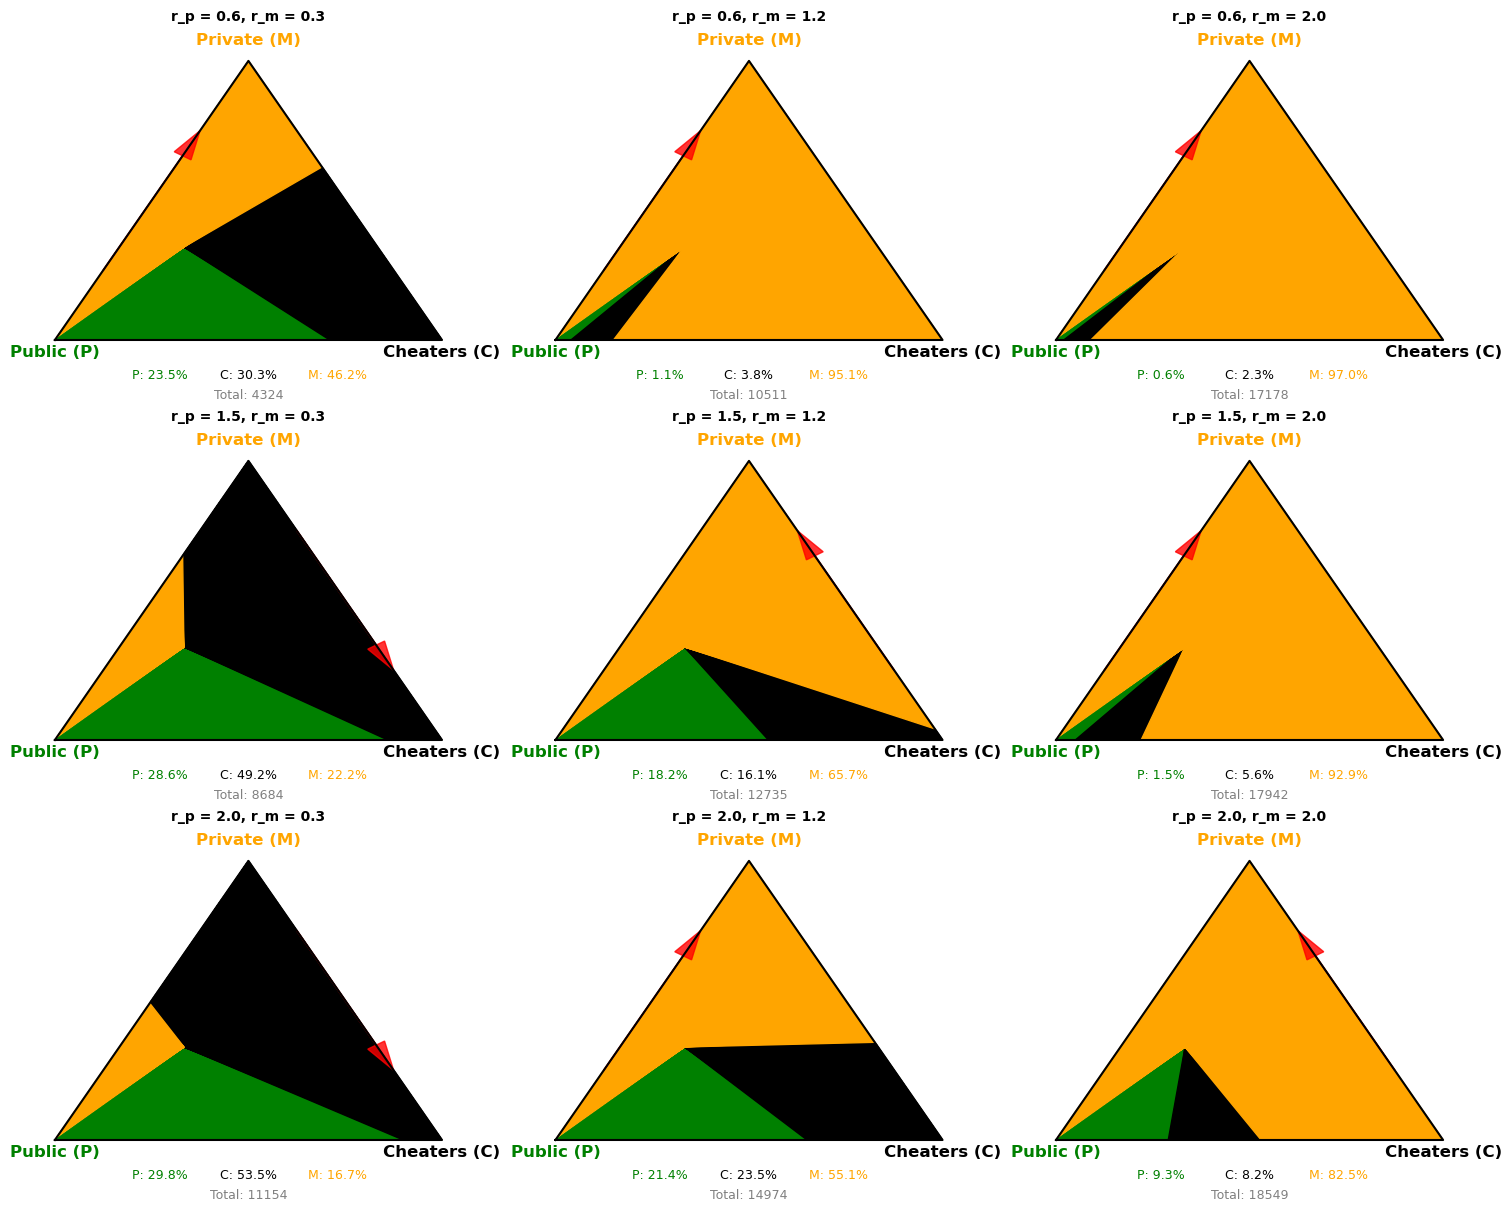

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import os

# Parameters
parameters = {
    "r_p": 0.02,
    "r_m": 0.02,
    "alpha": 0.0002,
    "beta": 0.0001,
    "eta": 0.0001,
    "gamma": 0.0001,
    "nu": 0.00001
}

# Growth rate variations
rp_values = [.6, 1.5, 2.0]
rm_values = [.3, 1.2, 2.0]

fig, axes = plt.subplots(len(rp_values), len(rm_values), figsize=(15, 12), constrained_layout=True)

# Function to convert barycentric coordinates to cartesian
def to_cartesian(x):
    return np.array([
        0.5 * (2 * x[:, 1] + x[:, 2]),
        np.sqrt(3) / 2 * x[:, 2]
    ]).T

for i, r_p_val in enumerate(rp_values):
    for j, r_m_val in enumerate(rm_values):
        current_parameters = parameters.copy()
        current_parameters["r_p"] = r_p_val
        current_parameters["r_m"] = r_m_val

        def population_dynamics(x, t, params):
            P, C, M = x
            dPdt = params["r_p"] * P - params["alpha"] * P * C - params["beta"] * P * M - params["eta"] * P ** 2
            dCdt = params["alpha"] * P * C - params["nu"] * C ** 2
            dMdt = params["r_m"] * M - params["beta"] * M * P - params["gamma"] * M ** 2
            return np.array([dPdt, dCdt, dMdt])

        # Generate barycentric grid
        num_points_density = 10
        barycentric_grid_density = []
        for a in range(num_points_density + 1):
            for b in range(num_points_density + 1 - a):
                c = num_points_density - a - b
                barycentric_grid_density.append([a / num_points_density, b / num_points_density, c / num_points_density])
        barycentric_grid_density = np.array(barycentric_grid_density)

        t = np.linspace(0, 300, 1000)
        final_populations = []

        for x0 in barycentric_grid_density:
            sol = odeint(population_dynamics, x0, t, args=(current_parameters,))
            final_state = sol[-1]
            final_populations.append(final_state)

        final_populations = np.array(final_populations)
        avg_final = np.mean(final_populations, axis=0)
        total = avg_final.sum()
        proportions = avg_final / total

        # Triangle vertices
        A = np.array([0, 0])  # Public (P)
        B = np.array([1, 0])  # Cheaters (C)
        C = np.array([0.5, np.sqrt(3)/2])  # Private (M)

        # Compute cumulative proportions
        cum_props = np.cumsum(np.concatenate([[0], proportions]))

        def point_on_triangle(p):
            if p <= 1/3:
                return A + (B - A) * (p * 3)
            elif p <= 2/3:
                return B + (C - B) * ((p - 1/3) * 3)
            else:
                return C + (A - C) * ((p - 2/3) * 3)

        # Build polygon segments
        resolution = 300
        boundary_points = []
        for k in range(resolution):
            frac = k / resolution
            if cum_props[0] <= frac < cum_props[1]:
                color = '#008000'  # Green for Public
            elif cum_props[1] <= frac < cum_props[2]:
                color = '#000000'  # Black for Cheaters
            else:
                color = '#FFA500'  # Orange for Private
            pt = point_on_triangle(frac)
            boundary_points.append((pt, color))

        ax = axes[i, j]

        # Fill triangle segments
        for k in range(len(boundary_points) - 1):
            pt1, color1 = boundary_points[k]
            pt2, color2 = boundary_points[k + 1]
            triangle = np.array([pt1, pt2, [1/3, np.sqrt(3)/6]])  # Triangle center-ish
            ax.fill(triangle[:, 0], triangle[:, 1], color=color1, edgecolor=color1)

        # Outline triangle
        triangle_vertices = np.array([A, B, C, A])
        ax.plot(triangle_vertices[:, 0], triangle_vertices[:, 1], 'k-', linewidth=1.5)

        # Add streamline arrow from min to max population
        vertices = [A, B, C]
        max_idx = np.argmax(proportions)
        min_idx = np.argmin(proportions)
        max_vertex = vertices[max_idx]
        min_vertex = vertices[min_idx]

        mid_x = (max_vertex[0] + min_vertex[0]) / 2
        mid_y = (max_vertex[1] + min_vertex[1]) / 2
        dx = max_vertex[0] - min_vertex[0]
        dy = max_vertex[1] - min_vertex[1]

        ax.arrow(mid_x - dx * 0.25, mid_y - dy * 0.25, dx * 0.5, dy * 0.5,
                 head_width=0.05, head_length=0.09, fc='red', ec='red', alpha=0.8,
                 length_includes_head=True)

        # Colored triangle vertex labels
        ax.text(0, -0.05, 'Public (P)', fontsize=12, fontweight='bold', ha='center', color='#008000')    # Green
        ax.text(1, -0.05, 'Cheaters (C)', fontsize=12, fontweight='bold', ha='center', color='#000000')  # Black
        ax.text(0.5, np.sqrt(3)/2 + 0.05, 'Private (M)', fontsize=12, fontweight='bold', ha='center', color='#FFA500')  # Orange

        # Colored population percentages
        ax.text(0.27, -0.12, f"P: {proportions[0]*100:.1f}%", fontsize=9, ha='center', color='#008000')
        ax.text(0.5, -0.12, f"C: {proportions[1]*100:.1f}%", fontsize=9, ha='center', color='#000000')
        ax.text(0.73, -0.12, f"M: {proportions[2]*100:.1f}%", fontsize=9, ha='center', color='#FFA500')

        # Total population as integer
        ax.text(0.5, -0.18, f"Total: {int(total)}", fontsize=9, ha='center', color='gray')

        # Title and axes settings
        ax.set_title(f"r_p = {r_p_val}, r_m = {r_m_val}", fontsize=10, fontweight="bold")
        ax.set_xlim(-0.1, 1.1)
        ax.set_ylim(-0.1, np.sqrt(3) / 2 + 0.1)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_frame_on(False)

# Save and show
os.makedirs("output/figures", exist_ok=True)
plt.savefig("output/figures/triangle_population_proportion_final.png", dpi=300)
plt.show()


# stream plot

If arrows point toward a corner ( toward "Private M"), it means the system evolves toward dominance of that population.

If arrows spiral or circulate, it means the system has oscillations or cycling between populations.

If arrows converge to a point inside, it shows a stable coexistence (a steady balance of Public, Cheaters, and Private).

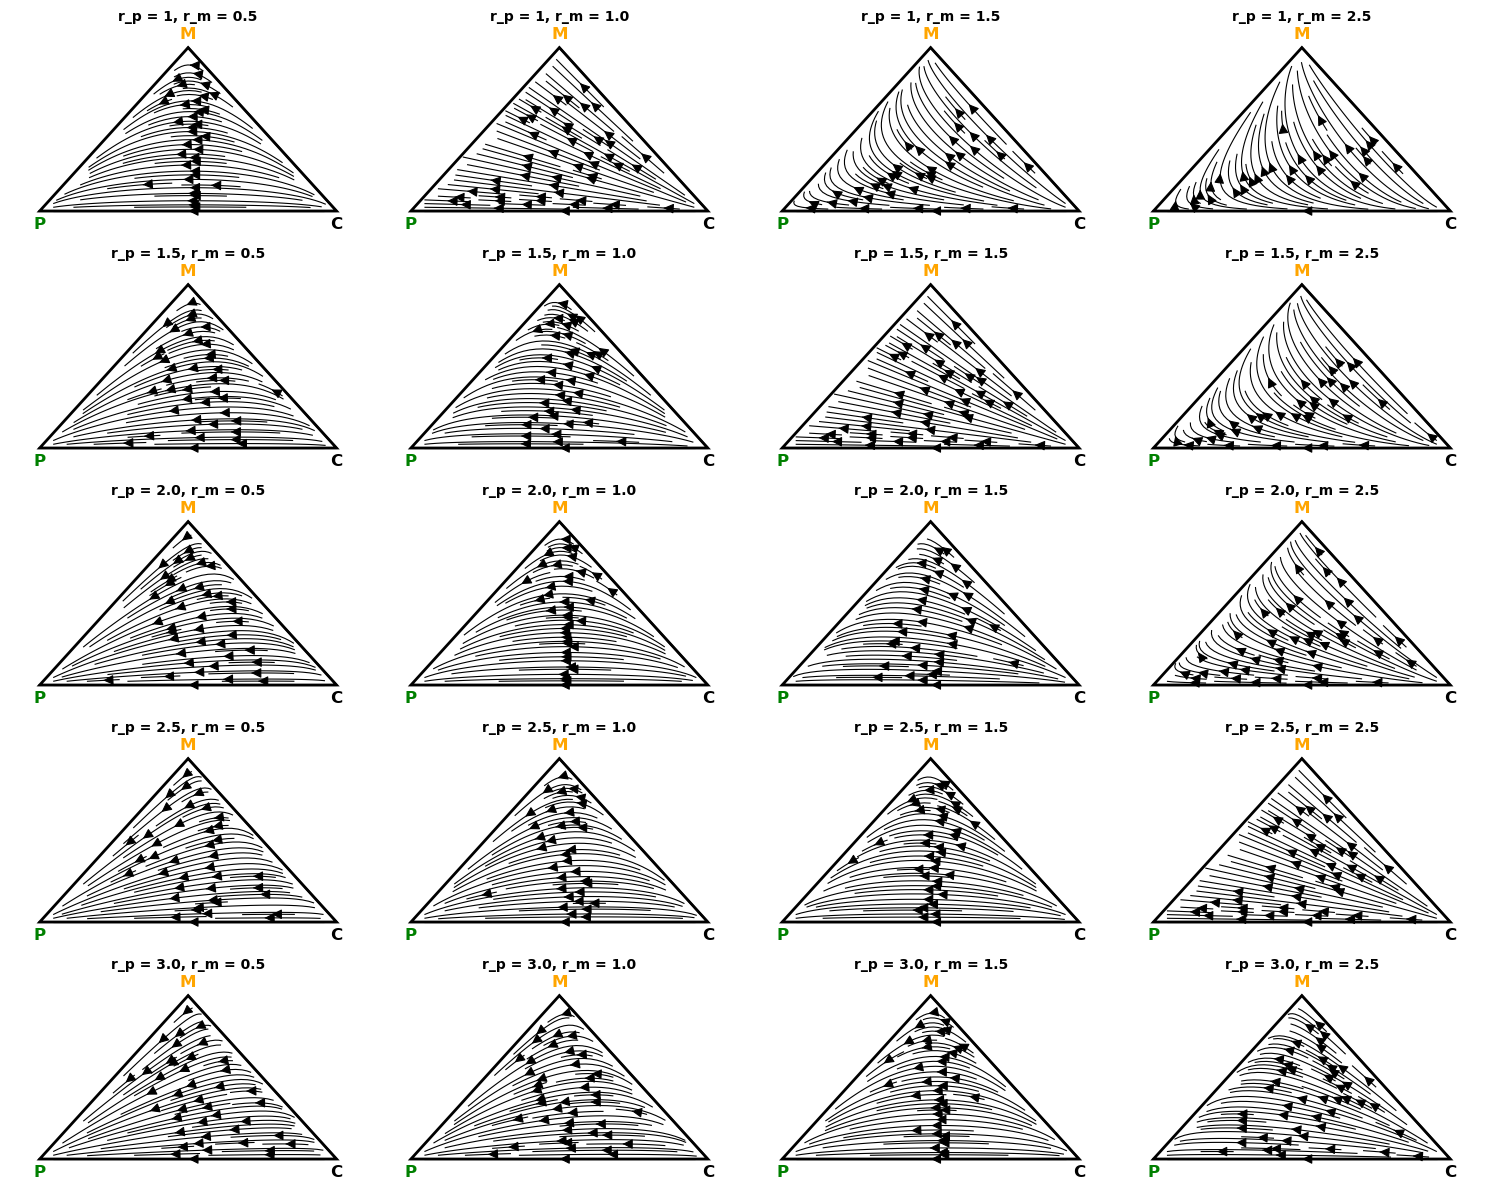

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import os

# Parameters as specified
parameters = {
    "beta": 0.0001,   # competition between public and private
    "gamma": 0.0001,  # cost of private
    "alpha": 0.0002,   # benefit to cheaters from public
    "eta": 0.0001,    # cost of public
    "r_p": 2.0,       # growth rate of public
    "r_m": 1.0,       # growth rate of private
    "nu": 0.00001      # cost for cheaters
}

# ODE system
def population_dynamics(x, t, params):
    P, C, M = x
    dPdt = params["r_p"] * P - params["alpha"] * P * C - params["beta"] * P * M - params["eta"] * P**2
    dCdt = params["alpha"] * P * C - params["nu"] * C**2
    dMdt = params["r_m"] * M - params["beta"] * M * P - params["gamma"] * M**2
    return np.array([dPdt, dCdt, dMdt])

# Barycentric to Cartesian for visualization
def to_cartesian(x):
    return np.array([
        0.5 * (2 * x[:, 1] + x[:, 2]),
        np.sqrt(3) / 2 * x[:, 2]
    ]).T

# Cartesian to Barycentric for visualization
def cartesian_to_barycentric(xy):
    x, y = xy[..., 0], xy[..., 1]
    l1 = 1 - x - y / np.sqrt(3)
    l2 = x - y / np.sqrt(3)
    l3 = 2 * y / np.sqrt(3)
    return np.stack([l1, l2, l3], axis=-1)

# Parameter sweep values
rp_values = [1, 1.5, 2.0, 2.5, 3.0]
rm_values = [0.5, 1.0, 1.5,2.5]

fig, axes = plt.subplots(len(rp_values), len(rm_values), figsize=(15, 12))

for i, rp in enumerate(rp_values):
    for j, rm in enumerate(rm_values):
        parameters["r_p"] = rp
        parameters["r_m"] = rm

        ax = axes[i, j]
        triangle_vertices = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])

        grid_size = 30
        x = np.linspace(0, 1, grid_size)
        y = np.linspace(0, np.sqrt(3)/2, grid_size)
        X, Y = np.meshgrid(x, y)
        XY = np.stack([X, Y], axis=-1)
        bary = cartesian_to_barycentric(XY)

        # Only keep points inside the simplex (initial condition proportions)
        mask = (bary >= 0).all(axis=-1)
        U = np.zeros_like(X)
        V = np.zeros_like(Y)

        for m in range(grid_size):
            for n in range(grid_size):
                if not mask[m, n]:
                    U[m, n] = V[m, n] = np.nan
                    continue

                x0 = bary[m, n]

                # Make initial total population larger if needed
                x0_scaled = x0 * 10  # optional scaling to "real" population sizes

                # Integrate without forcing P+C+M = 1
                sol = odeint(population_dynamics, x0_scaled, [0, 0.1], args=(parameters,))
                direction = sol[-1] - sol[0]

                # If direction is too small, treat as no flow
                if np.allclose(direction, 0):
                    U[m, n] = V[m, n] = 0
                    continue

                # If new point goes negative, mask it
                x1 = sol[-1]
                if np.any(x1 < 0):
                    U[m, n] = V[m, n] = 0
                    continue

                # Map starting and ending point to 2D
                start_cart = to_cartesian(np.array([x0]))[0]
                end_cart = to_cartesian(np.array([x1/np.sum(x1)]))[0]  # still use proportions to plot position
                vec = end_cart - start_cart

                U[m, n] = vec[0]
                V[m, n] = vec[1]

        # Plotting
        ax.streamplot(X, Y, U, V, color='black', linewidth=0.8, density=1.5, arrowsize=1.5)
        ax.plot(triangle_vertices[:, 0], triangle_vertices[:, 1], 'k-', linewidth=1.5)
        ax.fill(triangle_vertices[:, 0], triangle_vertices[:, 1], edgecolor='black', linewidth=2, fill=False)
        ax.text(0, -0.09, 'P', fontsize=12, fontweight='bold', ha='center', color='#008000')
        ax.text(1, -0.09, 'C', fontsize=12, fontweight='bold', ha='center',color='#000000')
        ax.text(0.5, np.sqrt(3)/2 + 0.05, 'M', fontsize=12, fontweight='bold', ha='center',color='#FFA500' )
        ax.set_title(f"r_p = {rp}, r_m = {rm}", fontsize=10, fontweight="bold")
        ax.set_xlim(-0.1, 1.1)
        ax.set_ylim(-0.1, np.sqrt(3)/2 + 0.1)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_frame_on(False)

# Save and show plot
plt.tight_layout()
os.makedirs("output/figures", exist_ok=True)
plt.savefig("output/figures/simplex_population_streamlines.png", dpi=300)
plt.show()





# Remarks Dated 17/04/2025
# All x0 + direction values end up outside the simplex (or are being projected poorly)
# I chnaged x2 = to_cartesian(np.array([x0 + direction]))[0]
#  to  
# # x1_bary = x0 + direction
#x1_bary = np.clip(x1_bary, 0, 1)        # Keep values non-negative
#total = np.sum(x1_bary)
#if total == 0:
 #   U[m, n] = V[m, n] = 0
 #   continue
#x1_bary /= total                        # Normalize so C + D + P = 1

####
#In my prev code, x0 + direction often didn’t stay inside the population simplex.
# As a result, when mapped to 2D, the difference x2 - x1 looked almost identical across the grid — causing all arrows to point similarly.
# The new version normalizes the result to ensure it's valid (C + D + P = 1), which gives each arrow its own true direction based on local dynamics.

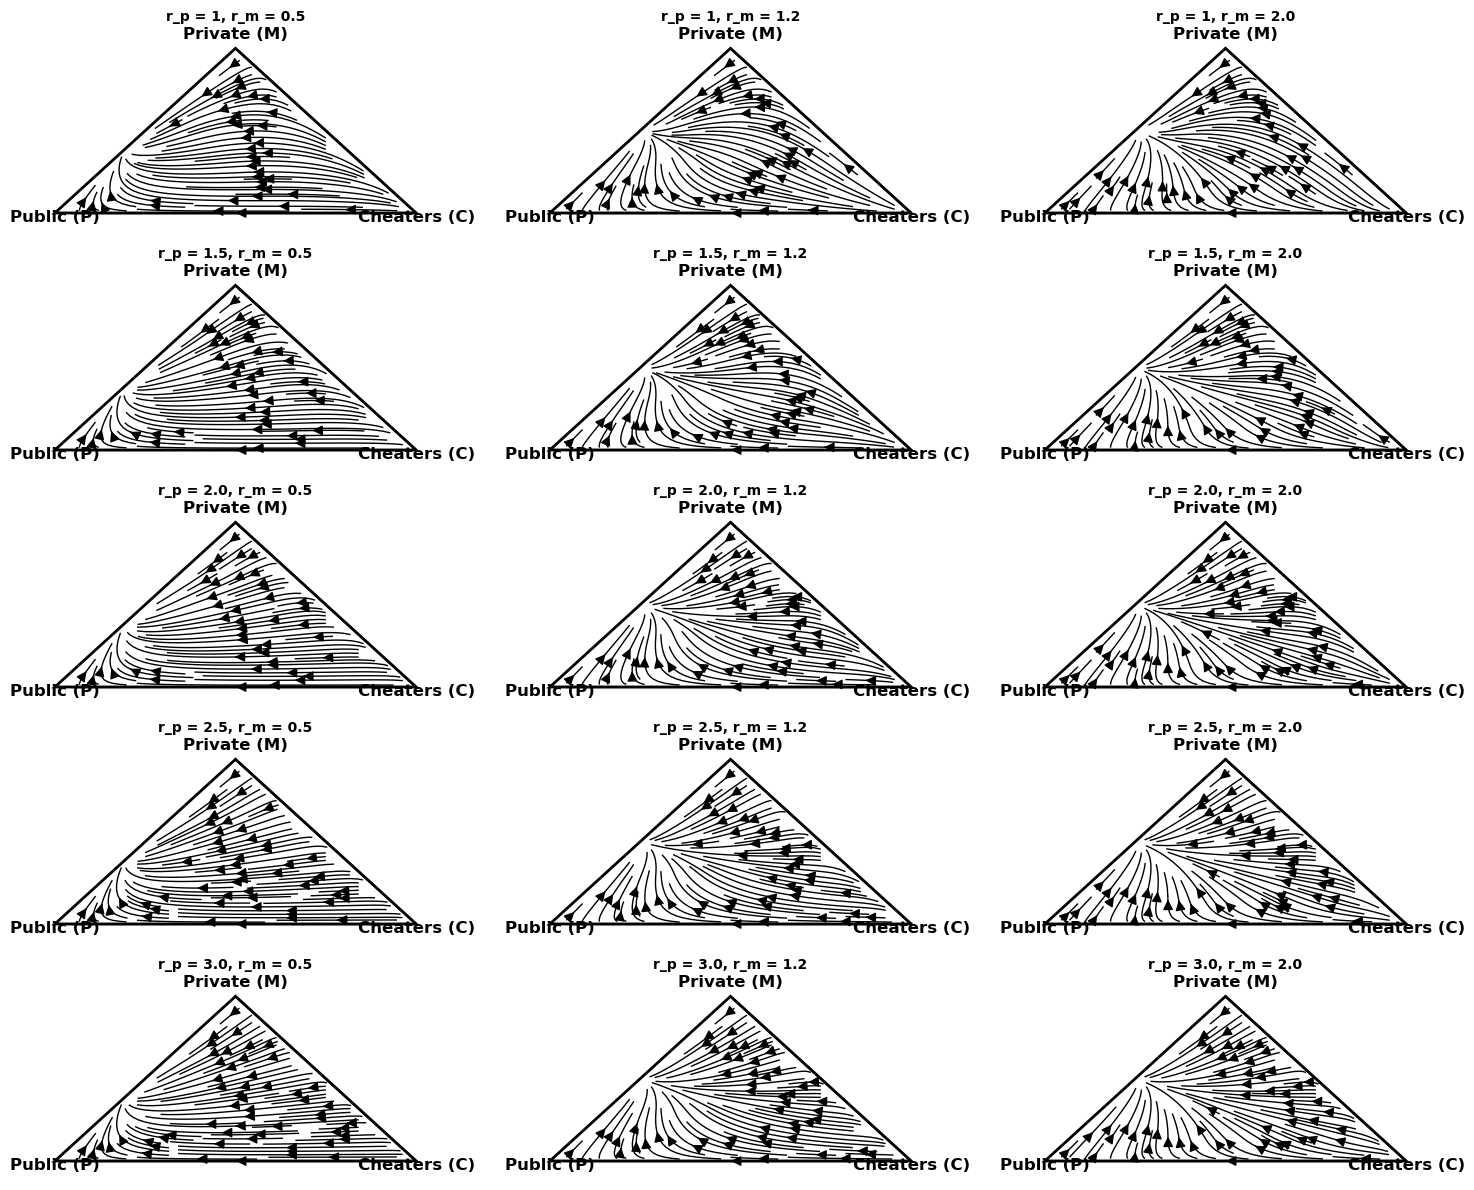

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import os

# Parameters as specified
parameters = {
    "beta": 0.0001,   # loss of public and private because of competition
    "gamma": 0.0001,  # cost spent by private population
    "alpha": 0.003,   # benefit from public to cheater
    "eta": 0.0001,    # cost spent by public population
    "r_p": 2.0,       # growth rate (benefit) of public
    "r_m": 1.0,       # growth rate (benefit) of private
    "nu": 0.0001      # transportation cost of cheater
}

# ODE system with updated format
def population_dynamics(x, t, params):
    P, C, M = x
    dPdt = params["r_p"] * P - params["alpha"] * P * C - params["beta"] * P * M - params["eta"] * P**2
    dCdt = params["alpha"] * P * C - params["nu"] * C**2
    dMdt = params["r_m"] * M - params["beta"] * M * P - params["gamma"] * M**2
    return np.array([dPdt, dCdt, dMdt])

# Barycentric to Cartesian
def to_cartesian(x):
    return np.array([
        0.5 * (2 * x[:, 1] + x[:, 2]),
        np.sqrt(3) / 2 * x[:, 2]
    ]).T

# Cartesian to Barycentric
def cartesian_to_barycentric(xy):
    x, y = xy[..., 0], xy[..., 1]
    l1 = 1 - x - y / np.sqrt(3)
    l2 = x - y / np.sqrt(3)
    l3 = 2 * y / np.sqrt(3)
    return np.stack([l1, l2, l3], axis=-1)

# Parameter variations
rp_values = [1, 1.5, 2.0, 2.5, 3.0]
rm_values = [0.5, 1.2, 2.0]

fig, axes = plt.subplots(len(rp_values), len(rm_values), figsize=(15, 12))

for i, rp in enumerate(rp_values):
    for j, rm in enumerate(rm_values):
        parameters["r_p"] = rp
        parameters["r_m"] = rm

        ax = axes[i, j]
        triangle_vertices = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])

        grid_size = 30
        x = np.linspace(0, 1, grid_size)
        y = np.linspace(0, np.sqrt(3)/2, grid_size)
        X, Y = np.meshgrid(x, y)
        XY = np.stack([X, Y], axis=-1)
        bary = cartesian_to_barycentric(XY)

        mask = (bary >= 0).all(axis=-1)
        U = np.zeros_like(X)
        V = np.zeros_like(Y)

        for m in range(grid_size):
            for n in range(grid_size):
                if not mask[m, n]:
                    U[m, n] = V[m, n] = np.nan
                    continue

                x0 = bary[m, n]
                sol = odeint(population_dynamics, x0, [0, 1], args=(parameters,))
                direction = sol[-1] - sol[0]

                if np.allclose(direction, 0):
                    U[m, n] = V[m, n] = 0
                    continue

                x1_bary = x0 + direction
                x1_bary = np.clip(x1_bary, 0, 1)
                total = np.sum(x1_bary)
                if total == 0:
                    U[m, n] = V[m, n] = 0
                    continue
                x1_bary /= total

                x1 = to_cartesian(np.array([x0]))[0]
                x2 = to_cartesian(np.array([x1_bary]))[0]
                vec = x2 - x1
                U[m, n] = vec[0]
                V[m, n] = vec[1]

        # Plotting
        ax.streamplot(X, Y, U, V, color='black', linewidth=1, density=1.5, arrowsize=1.5)
        ax.plot(triangle_vertices[:, 0], triangle_vertices[:, 1], 'k-', linewidth=1.5)
        ax.fill(triangle_vertices[:, 0], triangle_vertices[:, 1], edgecolor='black', linewidth=2, fill=False)
        ax.text(0, -0.05, 'Public (P)', fontsize=12, fontweight='bold', ha='center')
        ax.text(1, -0.05, 'Cheaters (C)', fontsize=12, fontweight='bold', ha='center')
        ax.text(0.5, np.sqrt(3)/2 + 0.05, 'Private (M)', fontsize=12, fontweight='bold', ha='center')
        ax.set_title(f"r_p = {rp}, r_m = {rm}", fontsize=10, fontweight="bold")
        ax.set_xlim(-0.1, 1.1)
        ax.set_ylim(-0.1, np.sqrt(3)/2 + 0.1)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_frame_on(False)

# Save and show plot
plt.tight_layout()
os.makedirs("output/figures", exist_ok=True)
plt.savefig("output/figures/simplex_population_streamlines_named.png", dpi=300)
plt.show()





# Remarks Dated 17/04/2025
# All x0 + direction values end up outside the simplex (or are being projected poorly)
# I chnaged x2 = to_cartesian(np.array([x0 + direction]))[0]
#  to  
# # x1_bary = x0 + direction
#x1_bary = np.clip(x1_bary, 0, 1)        # Keep values non-negative
#total = np.sum(x1_bary)
#if total == 0:
 #   U[m, n] = V[m, n] = 0
 #   continue
#x1_bary /= total                        # Normalize so C + D + P = 1

####
#In your prev code, x0 + direction often didn’t stay inside the population simplex.
# As a result, when mapped to 2D, the difference x2 - x1 looked almost identical across the grid — causing all arrows to point similarly.
# The new version normalizes the result to ensure it's valid (C + D + P = 1), which gives each arrow its own true direction based on local dynamics.

# problem 1

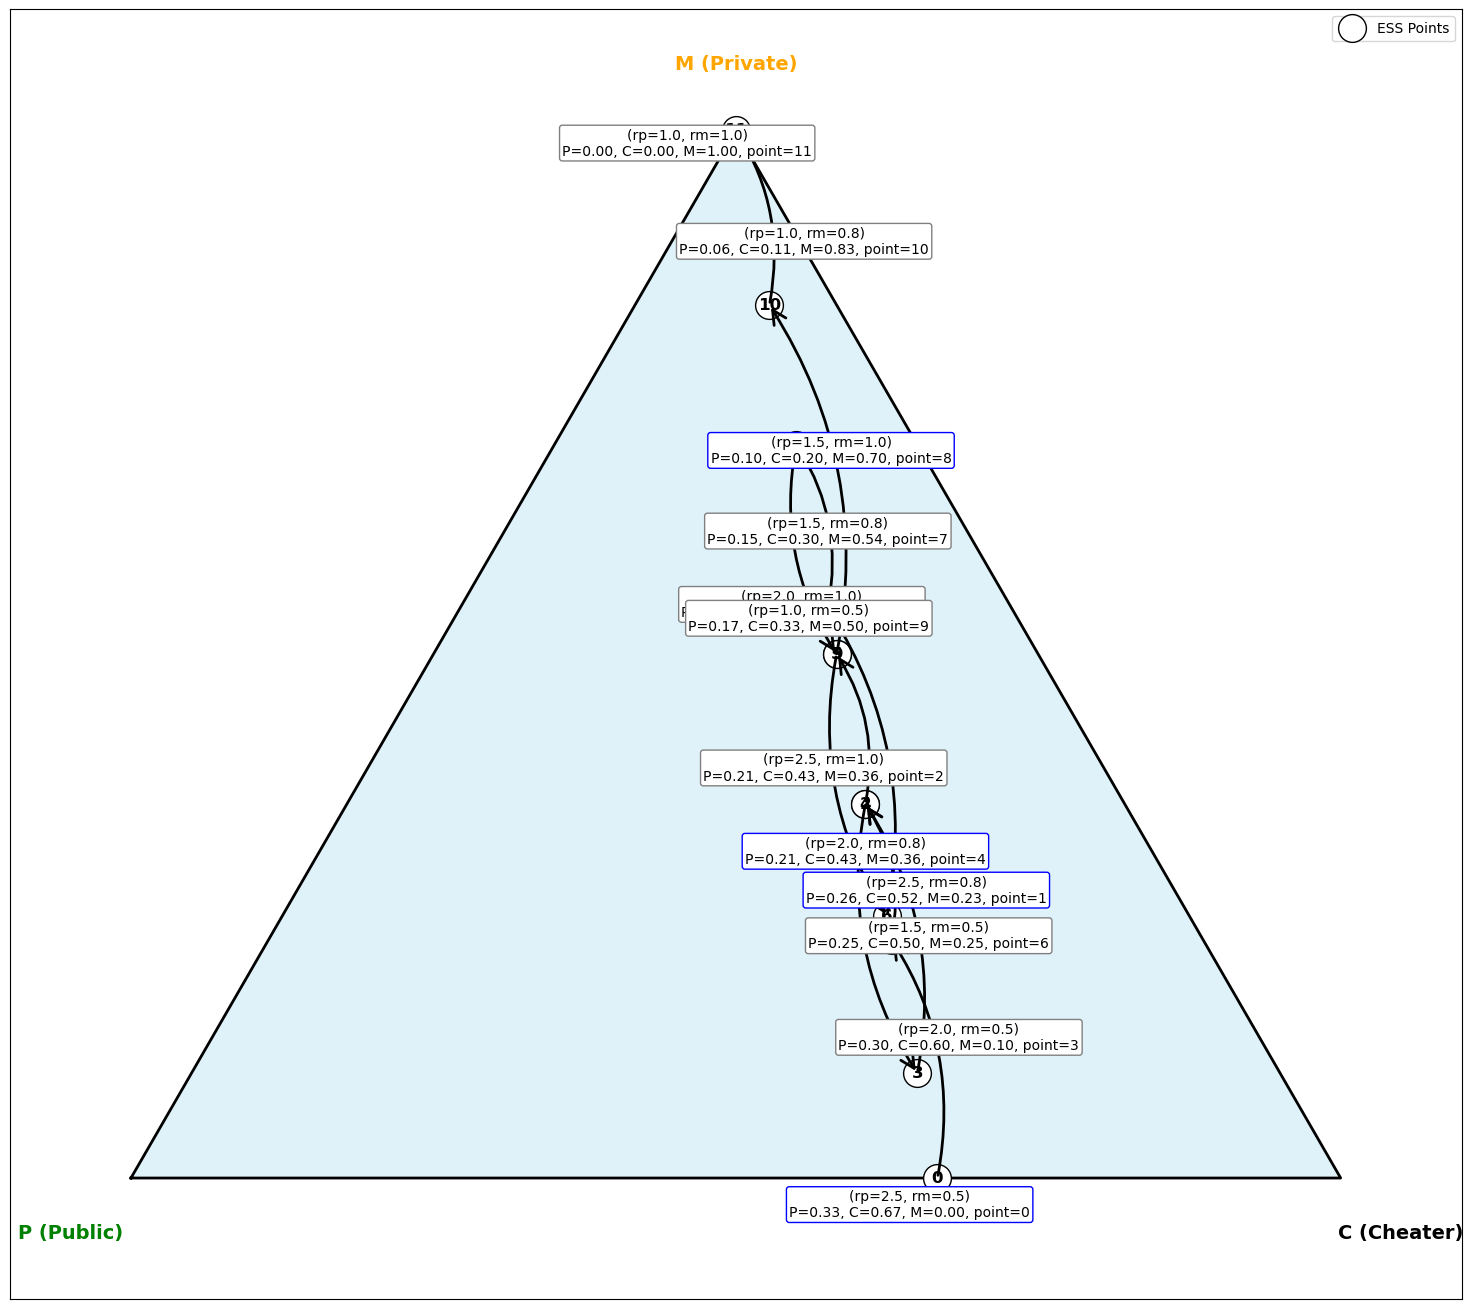

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Equilibrium calculation
def calculate_equilibrium(alpha, beta, gamma, nu, eta, rp, rm):
    denom = alpha**2 / nu + eta - beta**2 / gamma
    P = max(0, (rp - beta * rm / gamma) / denom)
    C = max(0, (alpha * P) / nu)
    M = max(0, (rm - beta * P) / gamma)
    tot = P + C + M
    return np.array([P, C, M]) / tot if tot > 0 else np.array([np.nan, np.nan, np.nan])

# Convert to simplex coords (swap P and M corners)
def to_triangular(m, c):
    x = c + 0.5 * m
    y = (np.sqrt(3) / 2) * m
    return x, y

# Parameters
alpha, beta, gamma, nu, eta = 0.0002, 0.0001, 0.0001, 0.0001, 0.0001
rp_vals = [2.5, 2.0, 1.5, 1.0]
rm_vals = [0.5, 0.8, 1.0]

# Updated offsets to reduce overlapping labels (indices 0‑14)
offsets = {
    0: (-20, -30),  1: (25, 25),  2: (-30, 15),  3: (30, 15),  4: (0, -45),
    5: (-25, 25),   6: (30, -25), 7: (0, 45),   8: (25, -15), 9: (-20, 15),
    10: (25, 35),  11: (-35, -20), 12: (35, -10), 13: (-10, 35), 14: (10, -35)
}

# Set up plot
fig, ax = plt.subplots(figsize=(15, 15))
# Triangle vertices
triangle = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3) / 2]])

# Light blue fill for the simplex
ax.fill(triangle[:, 0], triangle[:, 1], color='skyblue', alpha=0.25, zorder=0)

# Draw simplex boundary
triangle_closed = np.vstack([triangle, triangle[0]])
ax.plot(triangle_closed[:, 0], triangle_closed[:, 1], 'k-', lw=2, zorder=1)

# Plot points
points = []
for idx, (rp, rm) in enumerate((rp, rm) for rp in rp_vals for rm in rm_vals):
    P, C, M = calculate_equilibrium(alpha, beta, gamma, nu, eta, rp, rm)
    x, y = to_triangular(M, C)  # M at apex, C at bottom‑right, P at bottom‑left
    points.append((x, y))
    ax.plot(x, y, 'o', mec='black', mfc='white', ms=20,
            label='ESS Points' if idx == 0 else None, zorder=2)
    ax.text(x, y, str(idx), fontsize=12, fontweight='bold', ha='center', va='center', zorder=3)

# Annotate with predefined offsets and connect points with darker, larger‑headed arrows
for i, (rp, rm) in enumerate((rp, rm) for rp in rp_vals for rm in rm_vals):
    x, y = points[i]
    P, C, M = calculate_equilibrium(alpha, beta, gamma, nu, eta, rp, rm)
    text = f'(rp={rp:.1f}, rm={rm:.1f})\nP={P:.2f}, C={C:.2f}, M={M:.2f}, point={i}'
    dx, dy = offsets.get(i, (0, 20))
    edge_color = 'blue' if i in {0, 1, 4, 8} else 'gray'
    ax.annotate(text,
                xy=(x, y),
                xytext=(dx, dy),
                textcoords='offset points',
                ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=edge_color),
                zorder=3)

    # Darker, thicker arrows with larger arrow heads
    if i > 0:
        x0, y0 = points[i - 1]
        ax.annotate('', xy=(x, y), xytext=(x0, y0),
                    arrowprops=dict(arrowstyle='->', color='black', lw=2,
                                    mutation_scale=25,
                                    connectionstyle='arc3,rad=0.2'),
                    zorder=2)

# Corner labels
ax.text(-0.05, -0.05, 'P (Public)', ha='center', fontsize=14, fontweight='bold', color='#008000')
ax.text(1.05, -0.05, 'C (Cheater)', ha='center', fontsize=14, fontweight='bold', color='#000000')
ax.text(0.5, np.sqrt(3) / 2 + 0.05, 'M (Private)', ha='center', fontsize=14, fontweight='bold', color='#FFA500')

ax.legend(loc='upper right')
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, np.sqrt(3) / 2 + 0.1)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig("output/figures/triangle_ESS_proportion_final.png", dpi=300)
plt.show()


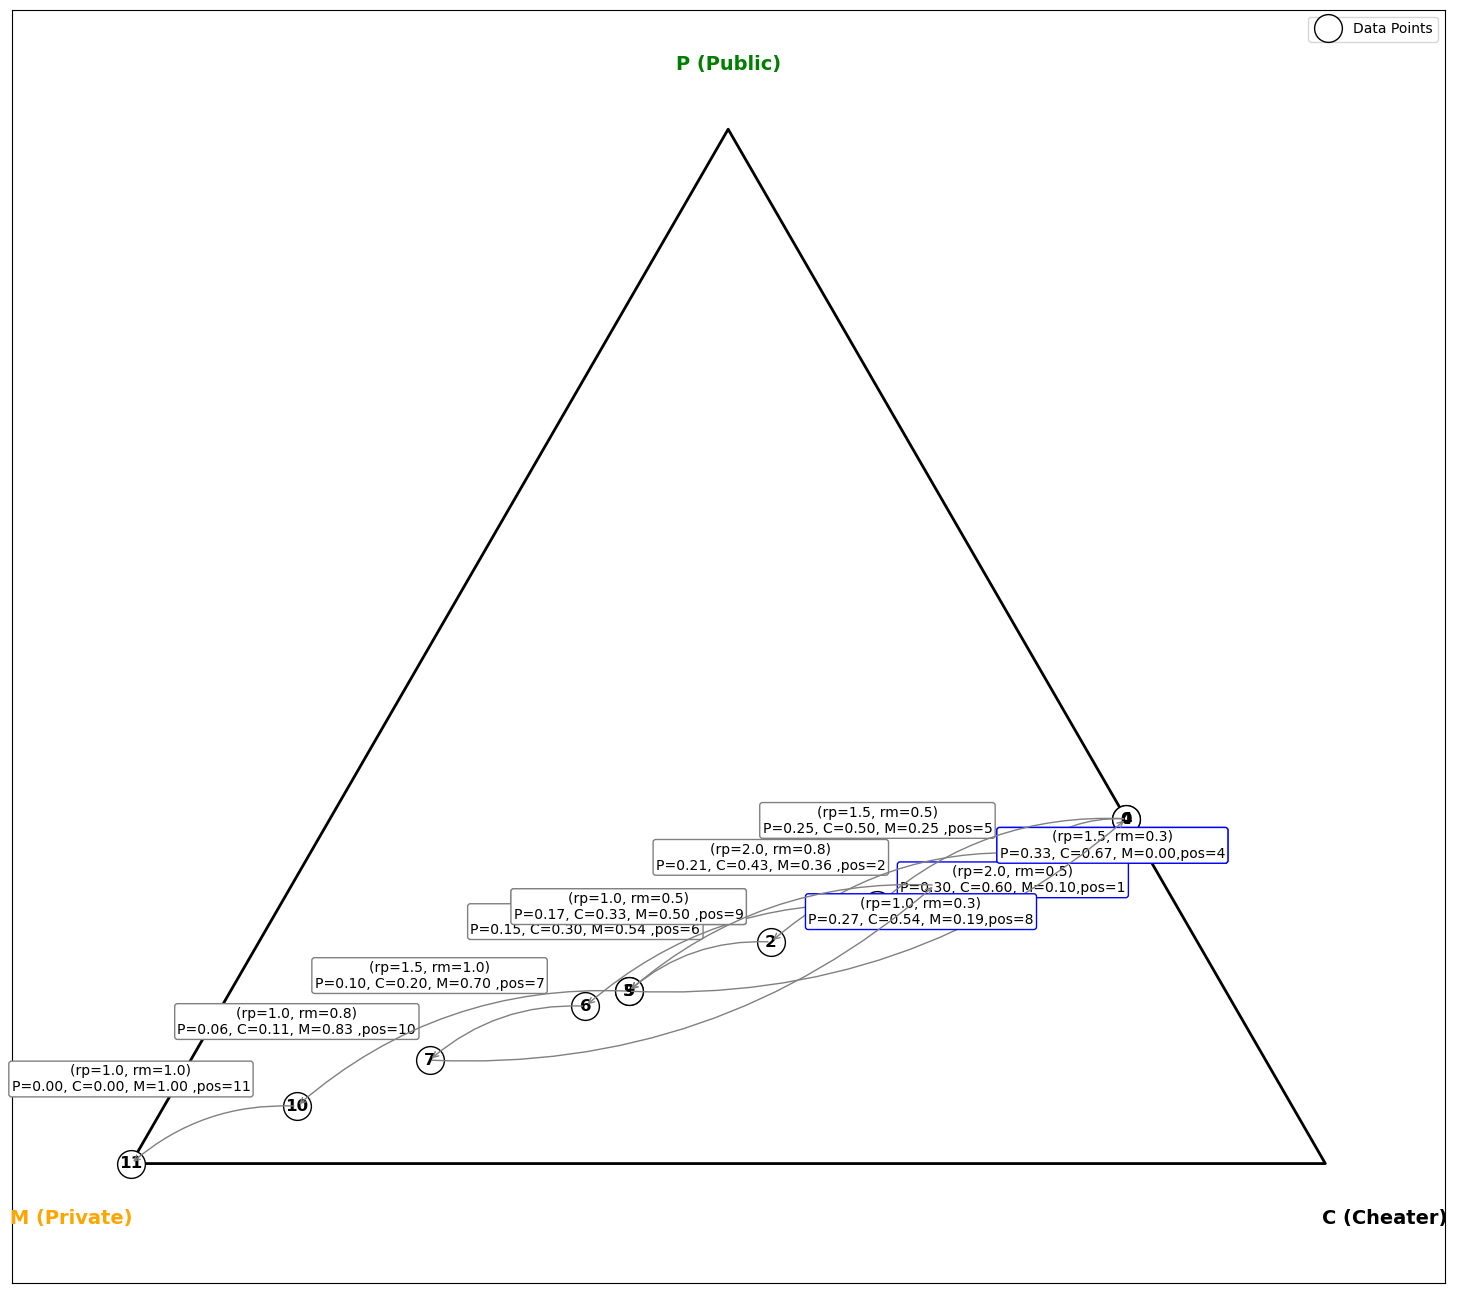

In [8]:
# Tanvir update 22.4
import numpy as np
import matplotlib.pyplot as plt

# Equilibrium calculation
def calculate_equilibrium(alpha, beta, gamma, nu, eta, rp, rm):
    denom = alpha**2/nu + eta - beta**2/gamma
    P = max(0, (rp - beta*rm/gamma)/denom)
    C = max(0, (alpha*P)/nu)
    M = max(0, (rm - beta*P)/gamma)
    tot = P + C + M
    return np.array([P, C, M])/tot if tot>0 else np.array([np.nan]*3)

# Convert to simplex coords
def to_triangular(p, c):
    x = c + 0.5*p
    y = (np.sqrt(3)/2)*p
    return x, y

# Params
alpha, beta, gamma, nu, eta = 0.0002,0.0001,0.0001,0.0001,0.0001
rp_vals = [2.0,1.5,1.0]
rm_vals = [0.5,0.8,1.0]

# Set up
fig, ax = plt.subplots(figsize=(15,15))
tri = np.array([[0,0],[1,0],[0.5,np.sqrt(3)/2],[0,0]])
ax.plot(tri[:,0],tri[:,1],'k-',lw=2)

# Plot & annotate
points = []
for idx, (rp, rm) in enumerate((rp, rm) for rp in rp_vals for rm in rm_vals):
    P,C,M = calculate_equilibrium(alpha,beta,gamma,nu,eta,rp,rm)
    x,y = to_triangular(P,C)
    points.append((x,y))
    ax.plot(x,y,'o',mec='black',mfc='white',ms=20,label='Data Points' if len(points)==1 else "")
    ax.text(x, y, str(idx), fontsize=12,fontweight='bold', ha='center', va='center', color='black')  # Position number added

for i,(rp,rm) in enumerate((rp,rm) for rp in rp_vals for rm in rm_vals):
    x,y = points[i]
    P,C,M = calculate_equilibrium(alpha,beta,gamma,nu,eta,rp,rm)
    if (i==1 or i==4 or i==8 or i==0):
          ax.annotate(f'(rp={rp:.1f}, rm={rm:.1f})\nP={P:.2f}, C={C:.2f}, M={M:.2f},pos={i}',
            xy=(x, y), 
            xytext=(-10,-30 ), 
            textcoords='offset points',
            ha='center', 
            va='bottom',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='blue'))
  
    else:
            ax.annotate(f'(rp={rp:.1f}, rm={rm:.1f})\nP={P:.2f}, C={C:.2f}, M={M:.2f} ,pos={i}',
            xy=(x, y), 
            xytext=(0, 50), 
            textcoords='offset points',
            ha='center', 
            va='bottom',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray'))


   
    if i>0:
        x0,y0 = points[i-1]
        ax.annotate('',xy=(x,y),xytext=(x0,y0,),
                    arrowprops=dict(arrowstyle='->',color='gray',lw=1,
                                    connectionstyle='arc3,rad=0.2'))

# Corner labels & legend
ax.text(0.5,np.sqrt(3)/2+0.05,'P (Public)',ha='center',fontsize=14,fontweight='bold', color='#008000')
ax.text(-0.05,-0.05,'M (Private)',fontsize=14,fontweight='bold', ha='center', color='#FFA500')
ax.text(1.05,-0.05,'C (Cheater)',fontsize=14,fontweight='bold', ha='center', color='#000000')
ax.legend(loc='upper right')

ax.set_xticks([]); ax.set_yticks([])
ax.set_xlim(-0.1,1.1); ax.set_ylim(-0.1,np.sqrt(3)/2+0.1)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


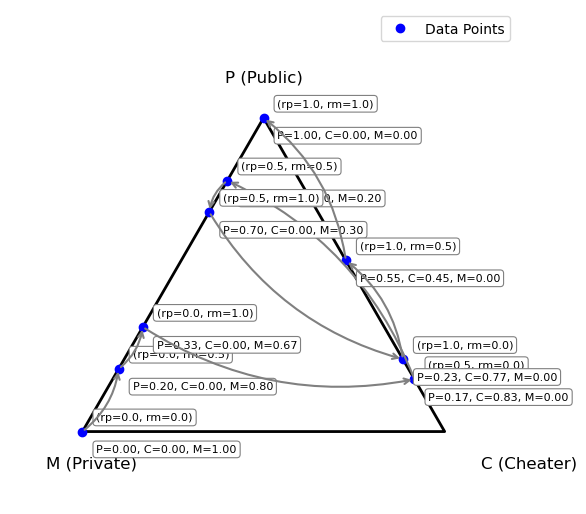

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_proportions(alpha, beta, gamma, nu, eta, rp, rm):
    denominator = alpha**2 - beta**2 - 2*beta*nu + gamma*eta + gamma*nu + eta*nu
    if denominator == 0:
        return None

    numerator_P = -alpha*gamma + alpha*rm - beta*nu - beta*rm + gamma*nu + gamma*rp + nu*rp - nu*rm
    numerator_C = -alpha*beta + alpha*gamma + alpha*rp - alpha*rm - beta**2 + beta*rp + beta*rm + gamma*eta - gamma*rp - eta*rm
    numerator_M = alpha**2 + alpha*beta - alpha*rp - beta*nu - beta*rp + eta*nu + eta*rm - nu*rp + nu*rm
    # ensures non neg (U Mo)
    P = max(0, numerator_P / denominator)
    C = max(0, numerator_C / denominator)
    M = max(0, numerator_M / denominator)

    total = P + C + M # If you take any numbers a, b, and c, and do this it sshould be P+C+M=1(U Mo)
    if total != 0:
        P /= total
        C /= total
        M /= total
    else:
        P = C = M = 1/3
        print("Warning: P + C + M = 0, setting them to equal proportions.")

    return np.array([P, C, M])

def create_triangle_axes(figsize=(6, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_frame_on(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
    return fig, ax

def cartesian_to_triangular(p, c):
    x = c + 0.5 * p
    y = (np.sqrt(3) / 2) * p
    x = np.clip(x, 0, 1)
    y = np.clip(y, 0, np.sqrt(3) / 2)
    if y > 0:
        x = np.clip(x, y / np.sqrt(3), 1 - y / np.sqrt(3))
    return x, y

def main():
    alpha = 0.5
    beta = 0.1
    gamma = 0.1
    nu = 0.1
    eta = 0.1

    rp_values = np.arange(.2, 2.0, 0.3)
    rm_values = np.arange(.2, 1.5, 0.3)

    results = {}
    point_sequence = []

    for rp in rp_values:
        for rm in rm_values:
            proportions = calculate_proportions(alpha, beta, gamma, nu, eta, rp, rm)
            if proportions is not None:
                results[(rp, rm)] = proportions
                point_sequence.append((rp, rm))
            else:
                results[(rp, rm)] = None

    p_values = []
    c_values = []
    valid_results = []
    all_proportions = []

    for (rp, rm), proportions in results.items():
        if proportions is not None:
            p_values.append(proportions[0])
            c_values.append(proportions[1])
            valid_results.append((rp, rm))
            all_proportions.append(proportions)

    fig, ax = create_triangle_axes()

    triangle_edges = np.array([
        [0, 0],  # M
        [1, 0],  # C
        [0.5, np.sqrt(3) / 2],  # P
        [0, 0]  # back to M
    ])
    ax.plot(triangle_edges[:, 0], triangle_edges[:, 1], 'k-', lw=2)

    triangular_points = [cartesian_to_triangular(p, c) for p, c in zip(p_values, c_values)]

    ax.plot([p[0] for p in triangular_points], [p[1] for p in triangular_points],
            'o', color='blue', label='Data Points')

    ax.text(-0.1, -0.1, 'M (Private)', fontsize=12)
    ax.text(0.5, np.sqrt(3) / 2 + 0.1, 'P (Public)', fontsize=12, ha='center')
    ax.text(1.1, -0.1, 'C (Cheater)', fontsize=12)

    ax.legend()

    for i, (rp, rm) in enumerate(valid_results):
        point = triangular_points[i]
        p_val, c_val, m_val = all_proportions[i]

        ax.annotate(
            f'(rp={rp:.1f}, rm={rm:.1f})',
            point,
            textcoords="offset points",
            xytext=(10, 8),
            ha='left',
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.8)
        )

        ax.annotate(
            f'P={p_val:.2f}, C={c_val:.2f}, M={m_val:.2f}',
            point,
            textcoords="offset points",
            xytext=(10, -15),
            ha='left',
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.8)
        )

        if i > 0:
            ax.annotate("",
                        xy=triangular_points[i],
                        xytext=triangular_points[i - 1],
                        arrowprops=dict(arrowstyle="->", color="gray", lw=1.5,
                                        connectionstyle="arc3,rad=0.2"))

    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.2, np.sqrt(3) / 2 + 0.3)
    #plt.title("Triangle Plot of P, C, M Proportions", fontsize=14)
    plt.tight_layout()
    plt.show()

    return results

if __name__ == "__main__":
    main()
